# Housing Price Regression Experiment

## kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation

This notebook presents a complete, reproducible, and academically rigorous regression experiment for the Housing Price dataset. It is prepared for direct use in **Chapter 7: Experiments and Results** of the thesis.

The experiment evaluates:

1. Baseline machine learning regressors
2. Repository-supported COBRA regression models
3. KFCProcedure regression models

Because this is a regression task, `CombinedClassifier` is documented as **not applicable** and is not used for model training.

## 1. Objective

### Purpose

The purpose of this experiment is to evaluate whether COBRA-based aggregation and KFCProcedure clusterwise learning improve regression performance on the Housing Price dataset compared with standard regression baselines.

### Research Questions

1. How do baseline regressors perform on the Housing Price regression task?
2. How do repository-supported COBRA regression models compare with baseline regressors?
3. How do KFCProcedure regression models compare with baseline and COBRA regression models?
4. Are the results stable across repeated train-test splits?

### Expected Evaluation

The task is regression. Therefore, the experiment uses MAE, MSE, RMSE, and R².

The repeated evaluation uses:

```python
SEEDS = [42, 52, 62, 72, 82]
```

## 2. Dataset Description

### 2.1 Dataset Overview

The dataset is the Kaggle California Housing Prices dataset, as used in the repository Housing Price regression notebook.

Repository-observed dataset source:

```text
camnugent/california-housing-prices
```

Repository-observed file:

```text
housing.csv
```

### 2.2 Feature Description

Observable features from the repository notebook include:

- `longitude`
- `latitude`
- `housing_median_age`
- `total_rooms`
- `total_bedrooms`
- `population`
- `households`
- `median_income`
- `ocean_proximity`

### 2.3 Target Variable

The target variable is:

```text
median_house_value
```

## 3. Import Libraries and Repository Modules

The notebook uses `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`, and repository modules from `kfc_procedure`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

### 3.1 Repository Import Configuration

The following cell imports the required repository classes. If the package is not installed, it searches for a local `src/kfc_procedure` directory.

In [2]:
def find_repo_root(start_path=None):
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "src" / "kfc_procedure").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing src/kfc_procedure. "
        "Run this notebook inside the kfc-procedure repository or install the package."
    )

try:
    from kfc_procedure.cobra.gradientcobra import GradientCOBRA
    from kfc_procedure.cobra.mixcobra import MixCOBRARegressor
    from kfc_procedure.kfc import KFCRegressor
    print("Repository classes imported from installed environment.")
except ImportError:
    repo_root = find_repo_root()
    sys.path.insert(0, str(repo_root / "src"))
    from kfc_procedure.cobra.gradientcobra import GradientCOBRA
    from kfc_procedure.cobra.mixcobra import MixCOBRARegressor
    from kfc_procedure.kfc import KFCRegressor
    print(f"Repository classes imported from source path: {repo_root / 'src'}")

Repository classes imported from installed environment.


## 4. Environment Configuration

Recording package versions supports reproducibility.

In [3]:
environment_table = pd.DataFrame({
    "Component": ["Python", "Platform", "NumPy", "Pandas", "Scikit-learn"],
    "Version": [platform.python_version(), platform.platform(), np.__version__, pd.__version__, sklearn.__version__],
})

environment_table

,Component,Version
0,Python,3.11.15
1,Platform,macOS-26.5.1-arm64-arm-64bit
2,NumPy,2.4.6
3,Pandas,3.0.3
4,Scikit-learn,1.9.0


## 5. Load Dataset

The dataset is loaded from Kaggle using `kagglehub`, following the repository Housing Price notebook.

In [4]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

DATASET_ID = "camnugent/california-housing-prices"
DATASET_FILE = "housing.csv"

dataset_path = dataset_download(DATASET_ID)
print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))

df_raw = pd.read_csv(os.path.join(dataset_path, DATASET_FILE))
df_raw.head()

Dataset path: /Users/ougi/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1
Files: ['housing.csv']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 6. Exploratory Data Analysis (EDA)

The EDA includes dataset shape, data types, missing values, duplicate count, target distribution, feature statistics, correlation analysis, and additional visualizations.

### 6.1 Dataset Shape

In [5]:
print("Raw dataset shape:", df_raw.shape)
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

Raw dataset shape: (20640, 10)
Rows: 20640
Columns: 10


### 6.2 Data Types

In [6]:
data_types_table = pd.DataFrame({
    "Feature": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
})

data_types_table

,Feature,Data Type
0,longitude,float64
1,latitude,float64
2,housing_median_age,float64
3,total_rooms,float64
4,total_bedrooms,float64
5,population,float64
6,households,float64
7,median_income,float64
8,median_house_value,float64
9,ocean_proximity,str


### 6.3 Missing Value Analysis

Missing values are checked using `df.isnull().sum()`. The repository notebook handles missing numerical values with median imputation and missing categorical values with most-frequent imputation inside the preprocessing pipeline.

In [7]:
missing_values_table = df_raw.isnull().sum().reset_index()
missing_values_table.columns = ["Feature", "Missing Values"]
missing_values_table["Missing Percentage"] = missing_values_table["Missing Values"] / len(df_raw) * 100
missing_values_table

,Feature,Missing Values,Missing Percentage
0,longitude,0,0.000000
1,latitude,0,0.000000
2,housing_median_age,0,0.000000
3,total_rooms,0,0.000000
4,total_bedrooms,207,1.002907
5,population,0,0.000000
6,households,0,0.000000
7,median_income,0,0.000000
8,median_house_value,0,0.000000
9,ocean_proximity,0,0.000000


### 6.4 Duplicate Analysis

Duplicate rows are inspected using `df.duplicated().sum()`. Duplicate removal is not observable from the provided Housing Price notebook.

In [8]:
duplicate_count = int(df_raw.duplicated().sum())
print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df_raw) * 100, 4), "%")

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


### 6.5 Target Distribution

Since this is a regression task, the target distribution is visualized as a histogram.

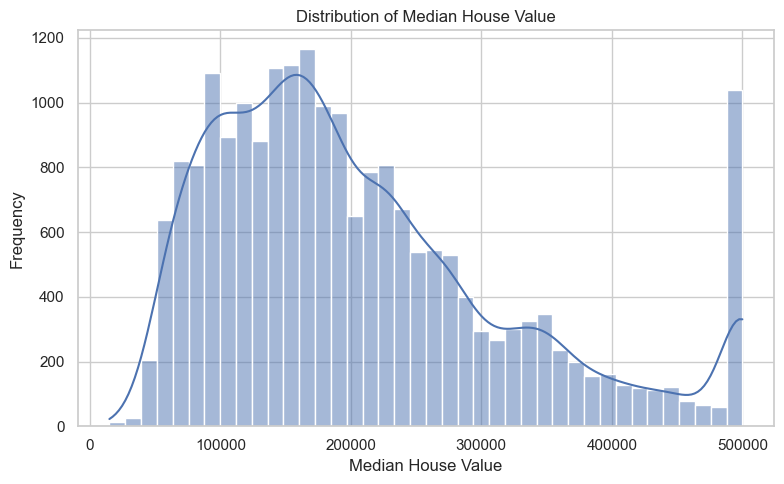

In [9]:
target = "median_house_value"

plt.figure(figsize=(8, 5))
sns.histplot(df_raw[target], bins=40, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 6.6 Feature Statistics

In [10]:
feature_statistics_table = df_raw.describe().T
feature_statistics_table

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


### 6.7 Correlation Analysis

The correlation matrix is computed for numerical columns only.

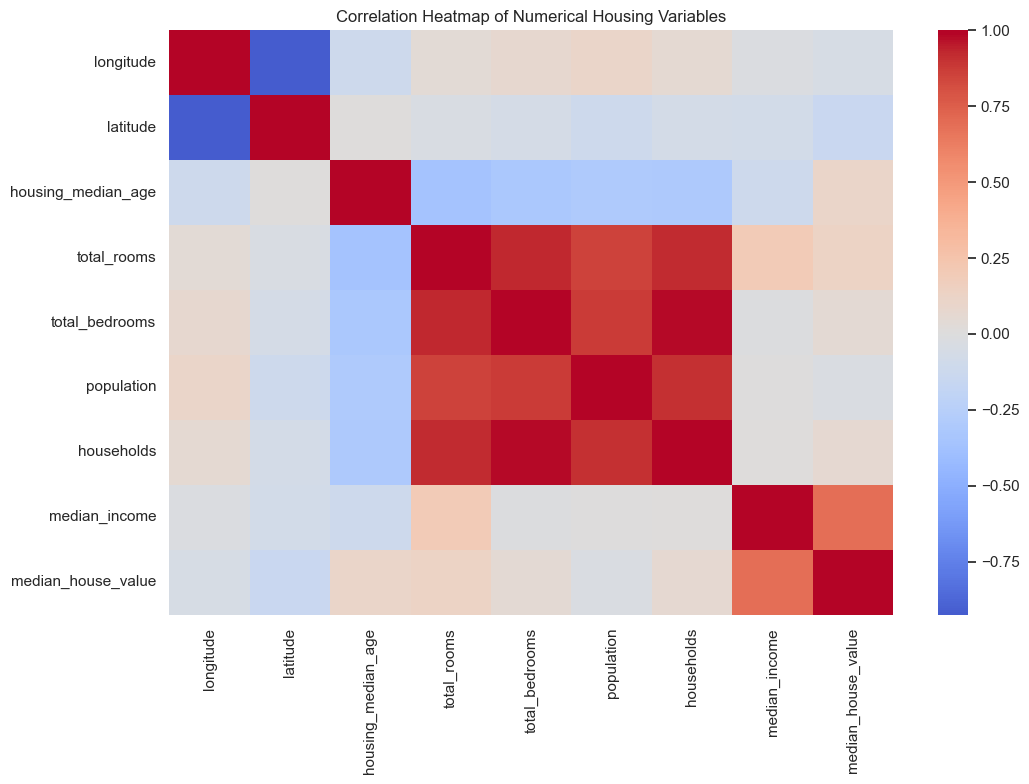

In [11]:
numeric_corr = df_raw.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(11, 8))
sns.heatmap(numeric_corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Housing Variables")
plt.tight_layout()
plt.show()

### 6.8 Additional Visualizations

The following scatter plot shows the relationship between `median_income` and the target variable. It is exploratory only and is not used for feature selection.

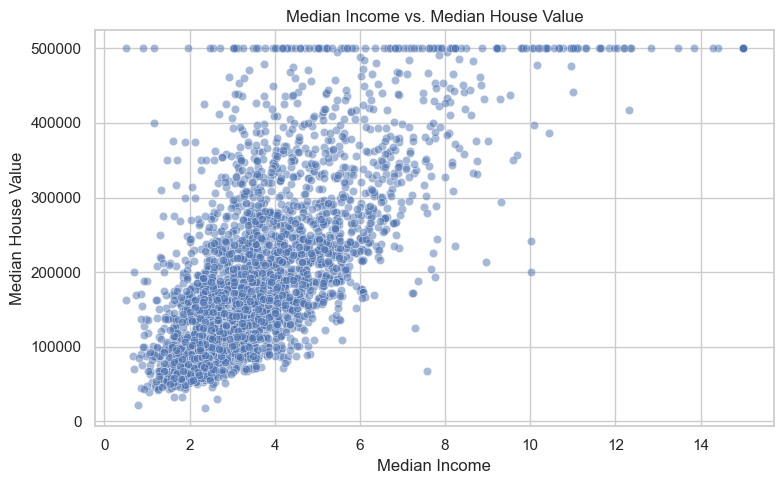

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_raw.sample(min(len(df_raw), 3000), random_state=42),
    x="median_income",
    y="median_house_value",
    alpha=0.5,
)
plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.tight_layout()
plt.show()

## 7. Data Cleaning

### 7.1 Missing Value Handling

Missing values are handled through scikit-learn preprocessing pipelines:

- Numerical variables: `SimpleImputer(strategy="median")`
- Categorical variables: `SimpleImputer(strategy="most_frequent")`

### 7.2 Duplicate Removal

Duplicate removal is **not observable from the provided materials**. Duplicate rows are inspected but not removed as an additional unverified intervention.

### 7.3 Outlier Inspection

Outlier inspection and outlier removal are **not observable from the provided materials**. No outlier filtering is applied.

### 7.4 Data Consistency Checks

The notebook verifies that the target column exists and is numeric.

In [13]:
df = df_raw.copy()

if target not in df.columns:
    raise ValueError(f"Target column {target} not found.")

if not pd.api.types.is_numeric_dtype(df[target]):
    raise TypeError("The target variable must be numeric for regression.")

print("Target column:", target)
print("Target dtype:", df[target].dtype)
print("Duplicate removal: Not observable from the provided materials; rows retained.")
print("Outlier removal: Not observable from the provided materials; no filtering applied.")

Target column: median_house_value
Target dtype: float64
Duplicate removal: Not observable from the provided materials; rows retained.
Outlier removal: Not observable from the provided materials; no filtering applied.


## 8. Data Preprocessing

### 8.1 Feature Encoding

The categorical column `ocean_proximity` is encoded using `OneHotEncoder(handle_unknown="ignore")`.

### 8.2 Feature Scaling

Two preprocessors are defined:

1. `standard_preprocessor` for baseline and COBRA regression models using `StandardScaler`.
2. `kfc_preprocessor` for KFCProcedure using `MinMaxScaler(feature_range=(0.05, 0.95))` to keep inputs positive for divergence-based clustering.

### 8.3 Feature Selection

Feature selection is **not observable from the provided materials**. All columns except the target are used.

### 8.4 Final Feature Matrix

The feature matrix is `X`; the target vector is `y`.

In [14]:
X = df.drop(columns=[target])
y = np.log(df[target])

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

X shape: (20640, 9)
y shape: (20640,)
Categorical columns: ['ocean_proximity']
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


In [15]:
standard_numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

kfc_numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler(feature_range=(0.05, 0.95))),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

standard_preprocessor = ColumnTransformer([
    ("num", standard_numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

kfc_preprocessor = ColumnTransformer([
    ("num", kfc_numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

## 9. Experimental Setup

### 9.1 Environment Configuration

The software environment was recorded earlier in this notebook.

### 9.2 Random Seed Configuration

```python
SEEDS = [42, 52, 62, 72, 82]
```

### 9.3 Train-Test Split Strategy

Each seed uses `train_test_split` with `test_size=0.2`. Stratification is not used because the target is continuous.

### 9.4 Hyperparameter Configuration

Baseline model families follow the repository Housing Price notebook:

- Ridge
- Random Forest Regressor
- SVR
- Gradient Boosting Regressor
- KNeighborsRegressor

COBRA regression models:

- GradientCOBRA
- MixCOBRARegressor

KFCProcedure models:

- KFCRegressor with GradientCOBRA combiner
- KFCRegressor with MixCOBRA combiner

### 9.5 Evaluation Protocol

For every seed, the experiment splits data, fits preprocessing on training data only, trains all models, predicts on the same test split, and stores all metrics in `all_results`.

In [16]:
SEEDS = [42, 52, 62, 72, 82]
TEST_SIZE = 0.2
PRIMARY_METRIC = "RMSE"

print("Seeds:", SEEDS)
print("Test size:", TEST_SIZE)
print("Primary metric:", PRIMARY_METRIC)

Seeds: [42, 52, 62, 72, 82]
Test size: 0.2
Primary metric: RMSE


## 10. Evaluation Metrics

### Mean Absolute Error (MAE)

\[
MAE = 
rac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
\]

Implemented with `mean_absolute_error(y_true, y_pred)`.

### Mean Squared Error (MSE)

\[
MSE = 
rac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\]

Implemented with `mean_squared_error(y_true, y_pred)`.

### Root Mean Squared Error (RMSE)

\[
RMSE = \sqrt{
rac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
\]

Implemented with `root_mean_squared_error(y_true, y_pred)`.

### Coefficient of Determination (R²)

\[
R^2 = 1 - 
rac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - ar{y})^2}
\]

Implemented with `r2_score(y_true, y_pred)`.

In [17]:
def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def to_dense_if_sparse(X_matrix):
    if hasattr(X_matrix, "toarray"):
        return X_matrix.toarray()
    return np.asarray(X_matrix)

## 11. Model Configuration

The following functions define the baseline, COBRA, and KFCProcedure models.

In [18]:
def make_baseline_models(seed):
    return {
        "Ridge": Ridge(alpha=1.0),
        "Random Forest Regressor": RandomForestRegressor(n_estimators=300, random_state=seed),
        "SVR": SVR(),
        "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=seed),
        "KNeighborsRegressor": KNeighborsRegressor(),
    }


def make_gradientcobra(seed):
    return GradientCOBRA(
        estimators=[
            "ridge",
            "random_forest_regressor",
            "svr",
            "gradient_boosting_regressor",
            "k_neighbors_regressor",
        ],
        random_state=seed,
    )


def make_mixcobra(seed):
    return MixCOBRARegressor(
        opt_method="grad",
        optimizer="gd",
        max_iter=100,
        learning_rate=1,
        random_state=seed,
    )


def make_kfc_gradientcobra(seed):
    return KFCRegressor(
        divergences=["euclidean", "gkl", "is"],
        local_model="linear_regression",
        combiner="gradientcobra",
        combiner_params={"max_iter": 50},
        n_clusters=3,
        random_state=seed,
    )


def make_kfc_mixcobra(seed):
    return KFCRegressor(
        divergences=["euclidean", "gkl", "is"],
        local_model="linear_regression",
        combiner="mixcobra",
        combiner_params={"max_iter": 20},
        n_clusters=3,
        random_state=seed,
    )

## 12. Baseline Models

For each baseline model, the experiment performs configuration, training, prediction, and evaluation on the same seed-specific split.

## 13. COBRA Experiments

### Configuration

The regression-appropriate COBRA models are `GradientCOBRA` and `MixCOBRARegressor`.

### Training, Prediction, and Evaluation

Each COBRA model is trained on the preprocessed training matrix and evaluated on the same test matrix.

### CombinedClassifier

`CombinedClassifier` is **not used** because it is a classification model and the Housing Price task is regression.

In [19]:
not_applicable_components = pd.DataFrame([
    {
        "Component": "CombinedClassifier",
        "Status": "Excluded",
        "Reason": "Classification model; not appropriate for continuous regression target median_house_value.",
    }
])

not_applicable_components

,Component,Status,Reason
0,CombinedClassifier,Excluded,Classification model; not appropriate for cont...


## 14. KFCProcedure Experiments

### Configuration

Two KFCProcedure regression models are evaluated:

1. `KFCRegressor-GradientCOBRA`
2. `KFCRegressor-MixCOBRA`

### K-Step

The K-Step uses divergence-based clustering with `euclidean`, `gkl`, and `is` divergences.

### F-Step

The F-Step uses cluster-wise `linear_regression` local models.

### C-Step

The C-Step aggregates intermediate predictions using either `gradientcobra` or `mixcobra`.

## 15. Repeated Evaluation Function

The following function executes one seed-specific experiment run.

In [20]:
def run_single_seed_experiment(seed, X, y):
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=seed,
    )

    X_train_standard = to_dense_if_sparse(standard_preprocessor.fit_transform(X_train))
    X_test_standard = to_dense_if_sparse(standard_preprocessor.transform(X_test))

    X_train_kfc = to_dense_if_sparse(kfc_preprocessor.fit_transform(X_train))
    X_test_kfc = to_dense_if_sparse(kfc_preprocessor.transform(X_test))

    seed_results = []

    for model_name, model in make_baseline_models(seed).items():
        start_fit = time.perf_counter()
        model.fit(X_train_standard, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_standard)
        predict_time = time.perf_counter() - start_predict

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **evaluate_regression(y_test, y_pred),
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    cobra_models = {
        "GradientCOBRA": make_gradientcobra(seed),
        "MixCOBRARegressor": make_mixcobra(seed),
    }

    for model_name, model in cobra_models.items():
        start_fit = time.perf_counter()
        model.fit(X_train_standard, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_standard)
        predict_time = time.perf_counter() - start_predict

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **evaluate_regression(y_test, y_pred),
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    kfc_models = {
        "KFCRegressor-GradientCOBRA": make_kfc_gradientcobra(seed),
        # "KFCRegressor-MixCOBRA": make_kfc_mixcobra(seed),
    }

    for model_name, model in kfc_models.items():
        start_fit = time.perf_counter()
        model.fit(X_train_kfc, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_kfc)
        predict_time = time.perf_counter() - start_predict

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **evaluate_regression(y_test, y_pred),
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    return seed_results

## 16. Execute Repeated Experiment

The required result storage object is `all_results = []`. Each row stores model name, seed, metric values, fit time, and prediction time.

In [21]:
def run_repeated_experiment(X, y, seeds):
    all_results = []
    for seed in seeds:
        print(f"Running experiment for seed = {seed}")
        all_results.extend(run_single_seed_experiment(seed, X, y))
    return all_results


if __name__ == "__main__":
    all_results = run_repeated_experiment(X, y, SEEDS)
    per_seed_results_table = pd.DataFrame(all_results)

per_seed_results_table

Running experiment for seed = 42


search: 100%|██████████| 300/300 [02:17<00:00,  2.18it/s]
iter=75 | score=0.0651 | grad_norm=0.0021:  75%|███████▌  | 75/100 [03:03<01:01,  2.44s/it]


KeyboardInterrupt: 

## 17. Results Summary

### 17.1 Per-Seed Results

The per-seed table reports each model's performance for each seed.

In [ ]:
per_seed_results_table = per_seed_results_table[
    ["Model", "Seed", "MAE", "MSE", "RMSE", "R2", "Fit Time", "Prediction Time"]
].sort_values(["Seed", "Model"]).reset_index(drop=True)

per_seed_results_table

### 17.2 Aggregated Results

The aggregated table reports mean and standard deviation across seeds.

In [ ]:
metric_columns = ["MAE", "MSE", "RMSE", "R2"]

aggregated_results_table = (
    per_seed_results_table
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
    .sort_values(("RMSE", "mean"), ascending=True)
)

aggregated_results_table

### 17.3 Mean ± Standard Deviation

In [ ]:
def format_mean_std(mean_value, std_value, decimals=3):
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"

formatted_aggregated_results = pd.DataFrame(index=aggregated_results_table.index)

for metric in metric_columns:
    formatted_aggregated_results[metric] = [
        format_mean_std(m, s)
        for m, s in zip(aggregated_results_table[(metric, "mean")], aggregated_results_table[(metric, "std")])
    ]

formatted_aggregated_results = formatted_aggregated_results.reset_index()
formatted_aggregated_results

### 17.4 Model Ranking

Models are ranked by mean RMSE. Lower RMSE is better.

In [ ]:
ranking_table = (
    aggregated_results_table[(PRIMARY_METRIC, "mean")]
    .reset_index()
    .rename(columns={(PRIMARY_METRIC, "mean"): f"Mean {PRIMARY_METRIC}"})
    .sort_values(f"Mean {PRIMARY_METRIC}", ascending=True)
    .reset_index(drop=True)
)

ranking_table.insert(0, "Rank", ranking_table.index + 1)
ranking_table

### 17.5 Best Model Analysis

In [ ]:
best_model_name = ranking_table.loc[0, "Model"]
best_model_rmse = ranking_table.loc[0, f"Mean {PRIMARY_METRIC}"]

print("Best model by mean RMSE:", best_model_name)
print("Mean RMSE:", round(best_model_rmse, 6))

formatted_aggregated_results[formatted_aggregated_results["Model"] == best_model_name]

## 18. Required Visualizations

The following cells generate target distribution, correlation heatmap, model comparison, ranking, and metric comparison charts.

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
comparison_plot_data = (
    aggregated_results_table[("RMSE", "mean")]
    .reset_index()
    .rename(columns={("RMSE", "mean"): "Mean RMSE"})
    .sort_values("Mean RMSE", ascending=True)
)

plt.figure(figsize=(11, 6))
sns.barplot(data=comparison_plot_data, x="Mean RMSE", y="Model", orient="h")
plt.title("Model Comparison by Mean RMSE")
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(11, 6))
sns.barplot(data=ranking_table, x=f"Mean {PRIMARY_METRIC}", y="Model", orient="h")
plt.title("Model Ranking by Mean RMSE")
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
mean_metric_table = per_seed_results_table.groupby("Model")[["MAE", "RMSE", "R2"]].mean().reset_index()
metric_comparison_long = mean_metric_table.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "R2"],
    var_name="Metric",
    value_name="Mean Score",
)

g = sns.catplot(
    data=metric_comparison_long,
    x="Mean Score",
    y="Model",
    col="Metric",
    kind="bar",
    sharex=False,
    height=5,
    aspect=0.9,
)
g.fig.suptitle("Metric Comparison Across Models", y=1.05)
for ax in g.axes.flat:
    ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

## 19. LaTeX-Ready Tables

The following tables are generated from computed results. No performance values are manually inserted.

In [ ]:
latex_per_seed_table = per_seed_results_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Per-seed Housing Price regression results.",
    label="tab:housing_per_seed_results",
)
print(latex_per_seed_table)

In [ ]:
latex_aggregated_table = formatted_aggregated_results.to_latex(
    index=False,
    escape=False,
    caption="Aggregated Housing Price regression results across five random seeds.",
    label="tab:housing_aggregated_results",
)
print(latex_aggregated_table)

In [ ]:
latex_ranking_table = ranking_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model ranking by mean RMSE for the Housing Price regression experiment.",
    label="tab:housing_model_ranking",
)
print(latex_ranking_table)

## 20. Discussion

### Comparison of Baselines

The baseline regressors provide the reference point for evaluating COBRA and KFCProcedure models. The comparison should be based on aggregated results rather than a single split.

### Comparison of COBRA Models

The COBRA regression models are `GradientCOBRA` and `MixCOBRARegressor`. `CombinedClassifier` is excluded because it is not applicable to regression.

### Comparison of KFC Models

The KFCProcedure models apply divergence-based clustering, local linear regression, and COBRA-based regression aggregation.

### Strengths

1. The experiment uses repeated evaluation over five seeds.
2. Preprocessing is fitted only on training data.
3. All models are evaluated on the same seed-specific test splits.
4. Mean and standard deviation are reported for every metric.

### Limitations

1. Outlier handling is not applied because it is not observable from the provided materials.
2. Feature selection is not applied because it is not observable from the provided materials.
3. COBRA and KFCProcedure methods may require high computation time.

### Threats to Validity

1. Rankings may change with different hyperparameters.
2. Results are specific to this dataset.
3. Spatial dependence in housing data may affect independence assumptions.
4. The target distribution is capped, which may affect error interpretation.

In [ ]:
baseline_model_names = [
    "Ridge",
    "Random Forest Regressor",
    "SVR",
    "Gradient Boosting Regressor",
    "KNeighborsRegressor",
]

baseline_ranking = ranking_table[ranking_table["Model"].isin(baseline_model_names)].reset_index(drop=True)
cobra_ranking = ranking_table[ranking_table["Model"].isin(["GradientCOBRA", "MixCOBRARegressor"])].reset_index(drop=True)
kfc_ranking = ranking_table[ranking_table["Model"].str.startswith("KFCRegressor")].reset_index(drop=True)

print("Baseline model ranking:")
display(baseline_ranking)

print("COBRA model ranking:")
display(cobra_ranking)

print("KFCProcedure model ranking:")
display(kfc_ranking)

## 21. Conclusion

This notebook implemented a complete Housing Price regression experiment for the thesis project:

**kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation**

The experiment evaluated baseline regressors, repository-supported COBRA regression models, and KFCProcedure regression models across five repeated train-test splits.

The final interpretation should be based on the generated per-seed, aggregated, and ranking tables. No performance claim should be made without referring to the computed values.

## 22. Reproducibility Checklist

- Dataset source is explicitly stated.
- Target column is explicitly defined.
- Random seeds are fixed.
- Train-test split configuration is fixed.
- Preprocessing is fitted only on training data.
- Missing values are handled using scikit-learn pipelines.
- Per-seed results are stored in `all_results`.
- Mean and standard deviation are reported.
- LaTeX-ready tables are generated from computed results.
- `CombinedClassifier` is explicitly excluded because it is not appropriate for regression.